In [2]:
!pip install seaborn pandas matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print(df['survived'].value_counts())
print(df['sex'].value_counts())
print(df['pclass'].value_counts())

survived
0    549
1    342
Name: count, dtype: int64
sex
male      577
female    314
Name: count, dtype: int64
pclass
3    491
1    216
2    184
Name: count, dtype: int64


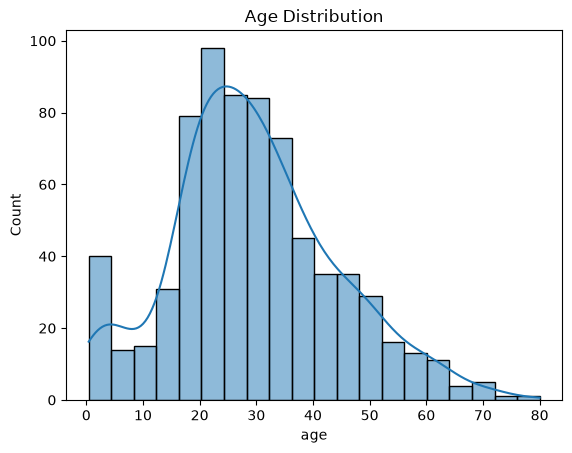

In [8]:
sns.histplot(df['age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

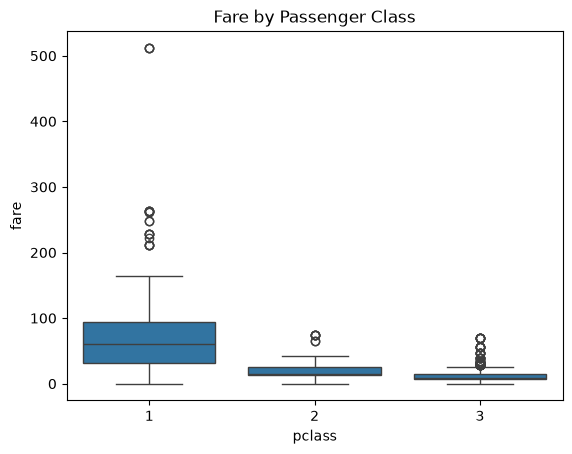

In [10]:
sns.boxplot(x='pclass', y='fare', data=df)
plt.title('Fare by Passenger Class')
plt.show()

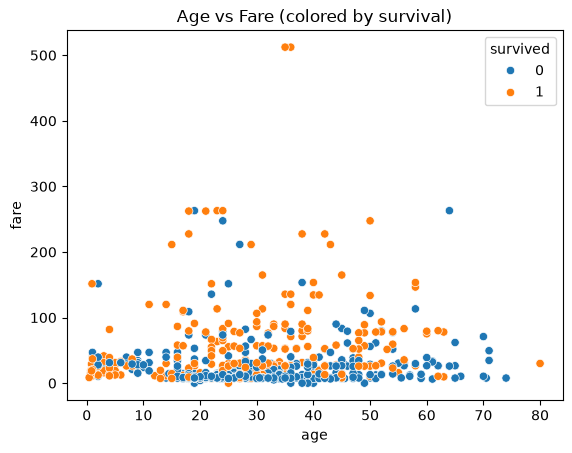

In [11]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Age vs Fare (colored by survival)')
plt.show()

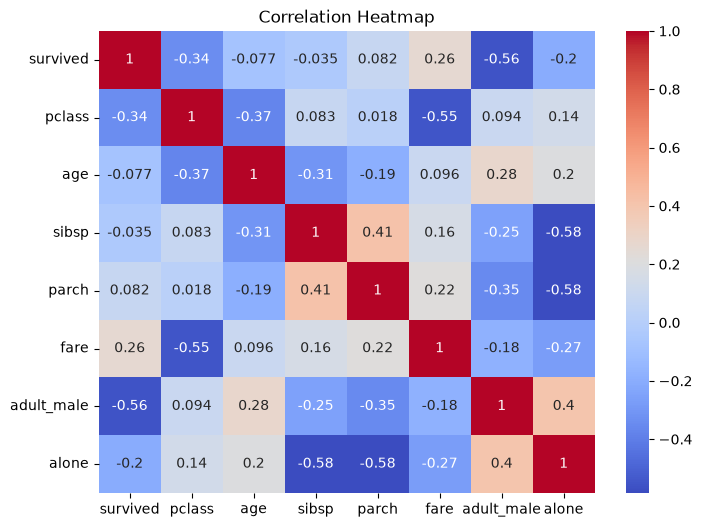

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
print(df.groupby('sex')['survived'].mean())
print(df.groupby('pclass')['survived'].mean())

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


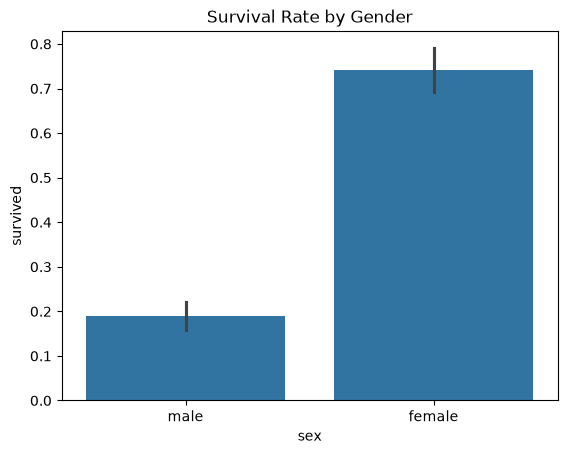

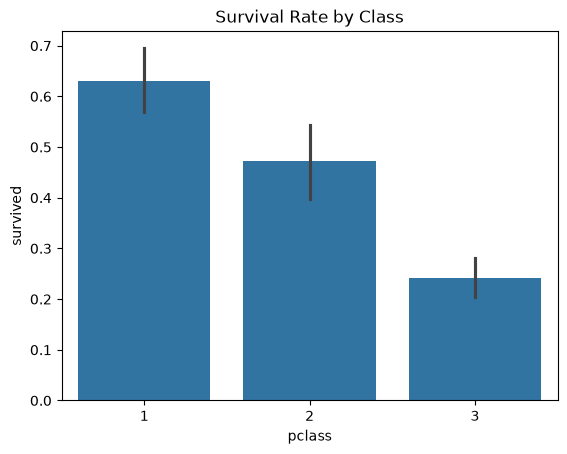

In [15]:
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

sns.barplot(x='pclass', y='survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

## Summary of Findings

- Survival rate by gender showed the biggest gap: **74.2% of females survived vs only 18.9% of males** — strong evidence of "women and children first."
- Survival also dropped steadily by class: **1st class 63%, 2nd class 47%, 3rd class 24%** — wealthier/higher-class passengers had much better survival odds.
- Overall, about 38% of all passengers survived.
- Most passengers traveled 3rd class (491 of 891), and there were nearly twice as many male as female passengers.
- Fare varied greatly by class — 1st class fares were far higher and more spread out (up to $512), while 3rd class fares were low and tightly clustered.
- Passengers who survived tended to have paid higher fares, reinforcing the class/wealth-survival link.
- Age had 177 missing values and deck had 688 missing — a data quality note.
- Age was roughly bell-shaped, peaking around 20-30 years old.